In [1]:
#Generate simulated temperature readings from two sensors
#Sensor A: mean 25 C, std 3, 200 readings
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = 9064.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(9064)
t = np.sort(rng.uniform(0, 10, size=200))
sensor_a = rng.normal(loc=25.0, scale=3.0, size=200)
sensor_b = rng.normal(loc=27.0, scale=4.5, size=200)

print(f"Sensor A: mean={sensor_a.mean():.2f}, std={sensor_a.std():.2f}")
print(f"Sensor B: mean={sensor_b.mean():.2f}, std={sensor_b.std():.2f}")

Sensor A: mean=25.23, std=2.98
Sensor B: mean=26.95, std=4.49


In [2]:
print(sensor_a.shape)
print(sensor_b.shape)
print(t.shape)

(200,)
(200,)
(200,)


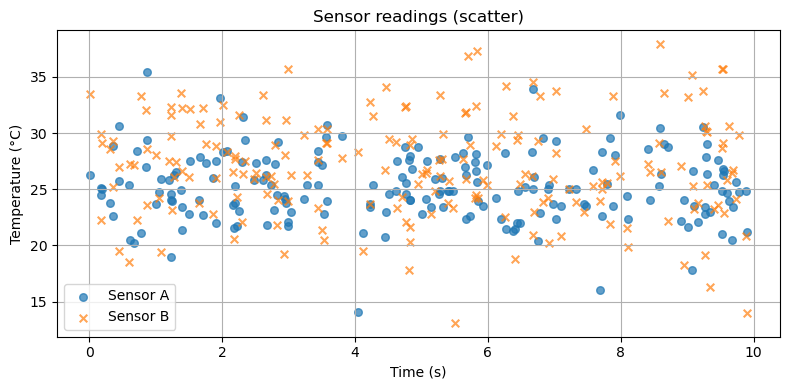

In [4]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(t, sensor_a, s=30, alpha=0.7, c='tab:blue', marker='o', label='Sensor A')
plt.scatter(t, sensor_b, s=30, alpha=0.7, c='tab:orange', marker='x', label='Sensor B')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Sensor readings (scatter)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\zafar\AppData\Local\Temp\ipykernel_28696\249984195.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sensor_a, sensor_b], labels=['Sensor A', 'Sensor B'])


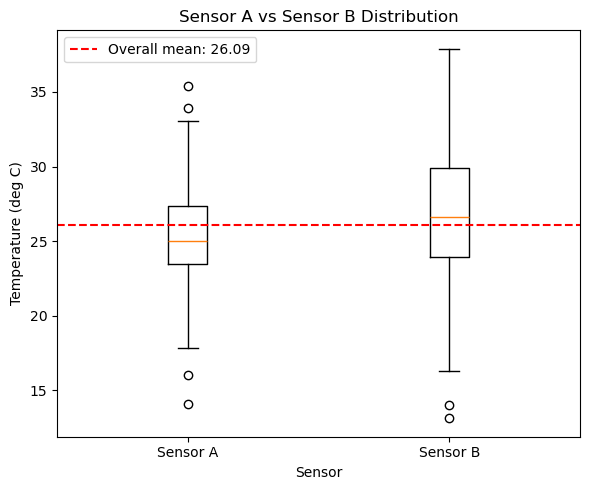

In [10]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([sensor_a, sensor_b], labels=['Sensor A', 'Sensor B'])
ax.set_xlabel('Sensor')
ax.set_ylabel('Temperature (deg C)')
ax.set_title('Sensor A vs Sensor B Distribution')

overall_mean = np.mean(np.concatenate([sensor_a, sensor_b]))
ax.axhline(overall_mean, color='red', linestyle='--', label=f'Overall mean: {overall_mean:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

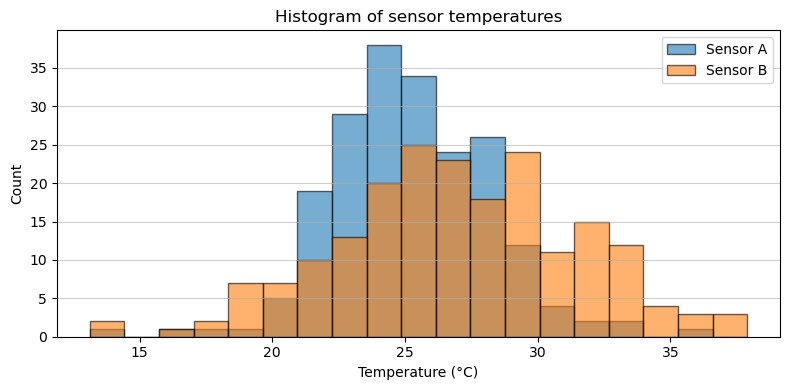

In [12]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

# Histogram of sensor readings
# Expects 'sensor_a' and 'sensor_b' arrays of shape (200,) in Celsius
import matplotlib.pyplot as plt
import numpy as np

if 'sensor_a' not in globals() or 'sensor_b' not in globals():
    raise NameError("sensor_a and sensor_b must exist in the notebook namespace")

# Choose shared bins across both sensors for direct comparison
bins = np.linspace(min(np.min(sensor_a), np.min(sensor_b)),
                   max(np.max(sensor_a), np.max(sensor_b)), 20)

plt.figure(figsize=(8,4))
plt.hist(sensor_a, bins=bins, alpha=0.6, color='tab:blue', label='Sensor A', edgecolor='black')
plt.hist(sensor_b, bins=bins, alpha=0.6, color='tab:orange', label='Sensor B', edgecolor='black')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Histogram of sensor temperatures')
plt.legend()
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()